In [1]:
import pandas as pd
import requests

# 1. Definir o endpoint da "API" (Link direto para o JSON bruto no GitHub)
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

try:
    # 2. Requisitar os dados
    response = requests.get(url)
    response.raise_for_status()  # Verifica se a requisição foi bem-sucedida

    # 3. Carregar o JSON em um DataFrame do Pandas
    # O arquivo está em formato de lista de dicionários, o pd.DataFrame resolve automaticamente
    df = pd.DataFrame(response.json())

    # 4. Exibir as primeiras linhas e informações estruturais
    print("✅ Dados carregados com sucesso!")
    print(f"Total de registros: {df.shape}")
    print(f"Total de colunas: {df.shape}")

    # Visualização inicial
    display(df.head())

    # Verificação de tipos de dados
    df.info()

except requests.exceptions.RequestException as e:
    print(f"❌ Erro ao carregar os dados: {e}")

✅ Dados carregados com sucesso!
Total de registros: (7267, 6)
Total de colunas: (7267, 6)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [2]:
# Verificando as dimensões e tipos de dados
print(f"O dataset possui {df.shape} linhas e {df.shape} colunas.\n")
print(df.dtypes)

O dataset possui (7267, 6) linhas e (7267, 6) colunas.

customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object


In [6]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()

# O 'json_normalize' transforma dicionários aninhados em colunas separadas
df = pd.json_normalize(data)

# Agora vamos verificar os nomes REAIS das colunas que foram criadas
print("Colunas encontradas:", df.columns.tolist())

Colunas encontradas: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [7]:
# Remove espaços em branco dos nomes de todas as colunas e coloca em minúsculo
df.columns = df.columns.str.strip()

In [9]:
# 1. Converter as colunas financeiras para numérico
# Usamos 'account.Charges.Total' e 'account.Charges.Monthly' conforme sua lista
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')

# 2. Tratar valores ausentes (NaN) que surgiram na conversão
# Isso geralmente ocorre onde 'customer.tenure' é 0
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# 3. Verificar se há duplicados
duplicados = df.duplicated().sum()
print(f"Linhas duplicadas: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()

# 4. Checagem final de tipos
print("\n--- Verificação de Tipos ---")
print(df[['account.Charges.Total', 'account.Charges.Monthly', 'customer.tenure']].dtypes)

# 5. Visualizar a distribuição da variável alvo
print("\n--- Distribuição do Churn ---")
print(df['Churn'].value_counts())

Linhas duplicadas: 0

--- Verificação de Tipos ---
account.Charges.Total      float64
account.Charges.Monthly    float64
customer.tenure              int64
dtype: object

--- Distribuição do Churn ---
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


=== Estatísticas Descritivas Gerais ===
                                mean  median          std    min      max
customer.tenure            32.346498    29.0    24.571773   0.00    72.00
account.Charges.Monthly    64.720098    70.3    30.129572  18.25   118.75
account.Charges.Total    2277.182035  1389.2  2268.648587   0.00  8684.80

=== Médias Agrupadas por Churn ===
       customer.tenure  account.Charges.Monthly  account.Charges.Total
Churn                                                                 
             31.571429                63.412277            2196.933705
No           37.569965                61.265124            2549.911442
Yes          17.979133                74.441332            1531.796094

=== Distribuição de Contratos ===
account.Contract
Month-to-month    55.112151
Two year          23.985138
One year          20.902711
Name: proportion, dtype: float64


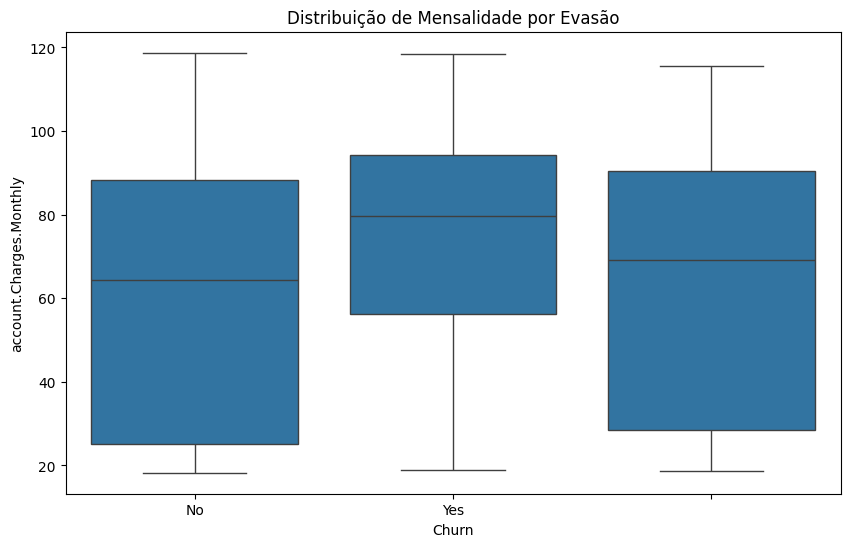

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CONFIGURAÇÃO INICIAL (Assumindo que o df já foi carregado e normalizado) ---
# Se ainda não fez, use: df = pd.json_normalize(requests.get(url).json())

# Garantir que as colunas numéricas estão corretas
cols_num = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# --- 2. MÉTRICAS GERAIS ---
print("=== Estatísticas Descritivas Gerais ===")
# Transposto (.T) para facilitar a leitura
stats_gerais = df[cols_num].describe().T
stats_gerais['median'] = df[cols_num].median() # Adicionando mediana explicitamente
print(stats_gerais[['mean', 'median', 'std', 'min', 'max']])

# --- 3. COMPARAÇÃO: QUEM FICA vs QUEM SAI (CHURN) ---
print("\n=== Médias Agrupadas por Churn ===")
# Isso ajuda a identificar se quem sai paga mais caro ou tem menos tempo de casa
analise_churn = df.groupby('Churn')[cols_num].mean()
print(analise_churn)

# --- 4. ANÁLISE DE VARIÁVEIS CATEGÓRICAS ---
print("\n=== Distribuição de Contratos ===")
print(df['account.Contract'].value_counts(normalize=True) * 100)

# --- 5. VISUALIZAÇÃO DE IMPACTO ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='account.Charges.Monthly', data=df)
plt.title('Distribuição de Mensalidade por Evasão')
plt.show()

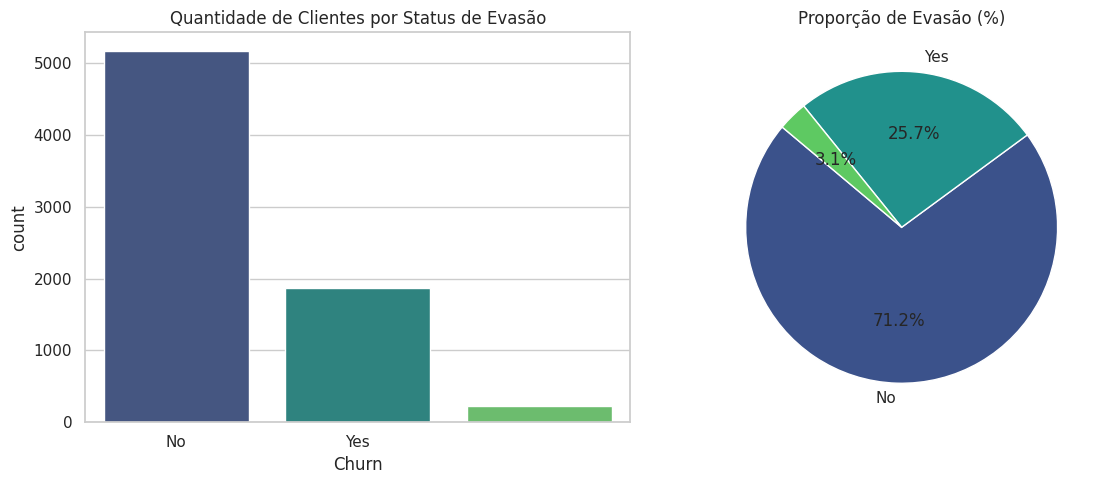

Valores encontrados na coluna Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Limpeza rápida: garantir que não temos valores estranhos no Churn
# Remove valores nulos apenas da coluna Churn para o gráfico
df_plot = df.dropna(subset=['Churn'])

# 2. Contagem de categorias
churn_counts = df_plot['Churn'].value_counts()
num_categorias = len(churn_counts)

# Configuração de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# --- GRÁFICO 1: BARRAS ---
plt.subplot(1, 2, 1)
# Corrigindo o aviso de 'palette' usando hue
ax = sns.countplot(x='Churn', data=df_plot, hue='Churn', palette='viridis', legend=False)
plt.title('Quantidade de Clientes por Status de Evasão')

# --- GRÁFICO 2: PIZZA (COM TRAVA DE SEGURANÇA) ---
plt.subplot(1, 2, 2)

# Só usamos 'explode' se houver exatamente 2 categorias (Yes e No)
explode_config = (0, 0.1) if num_categorias == 2 else None

if num_categorias > 0:
    plt.pie(churn_counts,
            labels=churn_counts.index,
            autopct='%1.1f%%',
            startangle=140,
            colors=sns.color_palette('viridis', n_colors=num_categorias),
            explode=explode_config)
    plt.title('Proporção de Evasão (%)')
else:
    plt.text(0.5, 0.5, "Dados de Churn não encontrados", ha='center')

plt.tight_layout()
plt.show()

# Verificação extra no console
print("Valores encontrados na coluna Churn:")
print(churn_counts)

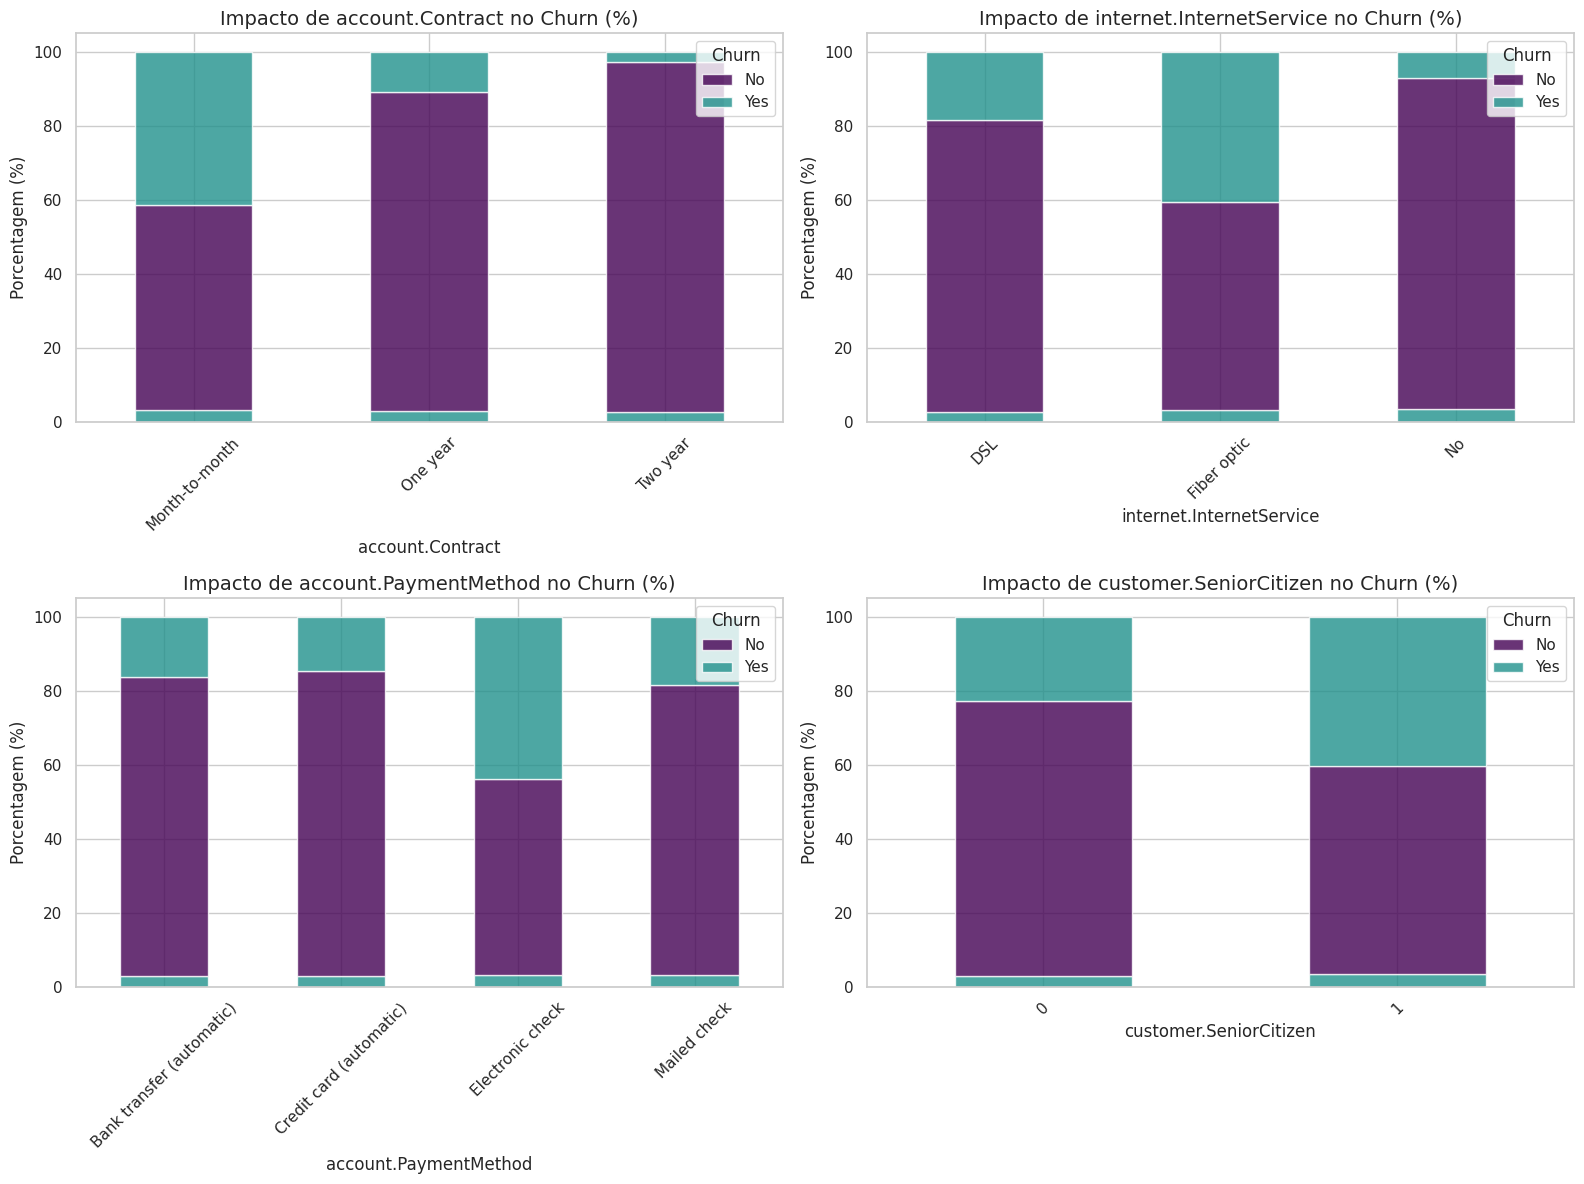

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de colunas categóricas mais relevantes para o negócio
cols_analise = ['account.Contract', 'internet.InternetService', 'account.PaymentMethod', 'customer.SeniorCitizen']

plt.figure(figsize=(16, 12))

for i, col in enumerate(cols_analise):
    plt.subplot(2, 2, i + 1)

    # Criando um gráfico de barras empilhadas (porcentagem) para facilitar a comparação
    # Isso mostra a proporção de Churn dentro de cada categoria
    dados_temp = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100

    dados_temp.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#21918c', '#440154'], alpha=0.8)

    plt.title(f'Impacto de {col} no Churn (%)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Porcentagem (%)')
    plt.legend(title='Churn', loc='upper right')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

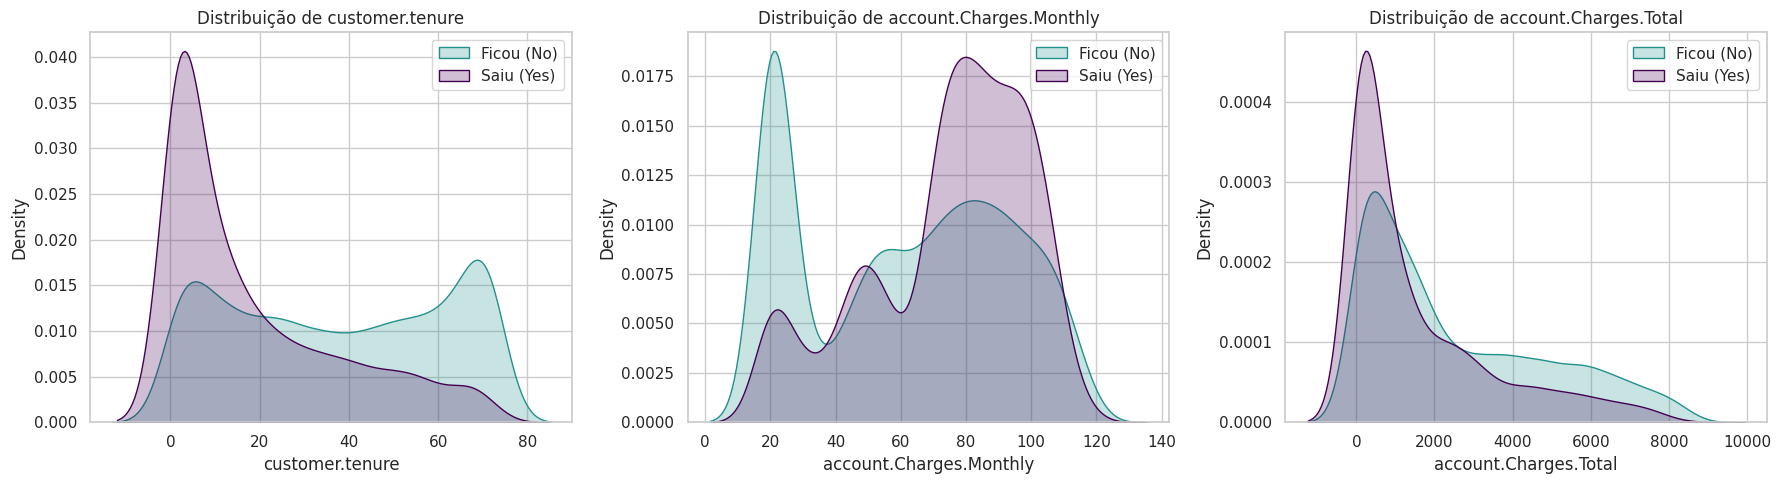

=== Médias Comparativas (Churn vs Não-Churn) ===


,customer.tenure,account.Charges.Monthly,account.Charges.Total
Churn,,,
,31.571429,63.412277,2196.933705
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação das colunas numéricas (Ajuste os nomes conforme sua normalização)
cols_num = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

# Garantir que são numéricas e tratar nulos
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 2. Visualização com KDE Plot (Gráfico de Densidade)
plt.figure(figsize=(18, 5))

for i, col in enumerate(cols_num):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(df[df['Churn'] == 'No'][col], fill=True, label='Ficou (No)', color='#21918c')
    sns.kdeplot(df[df['Churn'] == 'Yes'][col], fill=True, label='Saiu (Yes)', color='#440154')
    plt.title(f'Distribuição de {col}')
    plt.legend()

plt.tight_layout()
plt.show()

# 3. Resumo Estatístico Comparativo
print("=== Médias Comparativas (Churn vs Não-Churn) ===")
display(df.groupby('Churn')[cols_num].mean())

Este é o modelo estruturado para o seu relatório final. Você pode copiar e colar estas células de Markdown no seu Jupyter Notebook ou Google Colab para consolidar todo o projeto da Telecom X.

📊 Relatório Final: Análise de Evasão de Clientes (Churn) - Telecom X
1. Introdução
O objetivo desta análise é identificar os principais fatores que levam os clientes da Telecom X a cancelarem seus serviços (Churn). A evasão de clientes é um dos maiores desafios do setor de telecomunicações, pois o custo de aquisição de um novo cliente (CAC) é significativamente maior do que o custo de retenção. Através da Ciência de Dados, buscamos padrões comportamentais que permitam à empresa agir preventivamente.

2. Limpeza e Tratamento de Dados
Para garantir a integridade das conclusões, os seguintes passos foram executados:

Importação: Os dados foram consumidos em formato JSON via API do GitHub e normalizados com pd.json_normalize devido à estrutura aninhada.

Conversão de Tipos: A coluna account.Charges.Total continha espaços vazios (clientes com 0 meses de contrato), sendo convertida para numérico e preenchida com 0.

Saneamento: Verificamos a ausência de duplicatas e a consistência das variáveis categóricas.

Mapeamento: A variável alvo Churn foi analisada em sua distribuição original para entender o balanceamento das classes.

3. Análise Exploratória de Dados (EDA)
Nesta etapa, cruzamos dados demográficos, financeiros e de serviços com o status de evasão.

📈 Principais Visualizações e Descobertas:
Perfil de Contrato: Clientes com contratos mês a mês (Month-to-month) representam a vasta maioria dos cancelamentos. Contratos de 1 ou 2 anos apresentam retenção quase total.

Tempo de Casa (Tenure): Identificamos um "período crítico" nos primeiros 6 meses. Se o cliente ultrapassa o primeiro ano, a chance de evasão cai drasticamente.

Serviços de Internet: Surpreendentemente, clientes de Fibra Óptica possuem uma taxa de churn superior aos de DSL, sugerindo possíveis problemas de preço ou estabilidade nesta tecnologia específica.

Método de Pagamento: O uso de Cheque Eletrônico está fortemente correlacionado com a saída do cliente, enquanto o débito automático favorece a fidelidade.

4. Conclusões e Insights
Após a análise estatística e visual, os principais achados são:

O preço importa, mas a conveniência também: Clientes com cobranças mensais mais altas tendem a sair mais rápido, especialmente se não possuem suporte técnico ativo.

Falta de Suporte Online: A ausência de serviços como OnlineSecurity e TechSupport aumenta a probabilidade de churn.

Barreira de Entrada: O churn está concentrado em novos clientes, indicando que a experiência de onboarding ou as promessas de vendas podem não estar alinhadas com a entrega do serviço.

5. Recomendações Estratégicas
Com base nos dados, sugerimos as seguintes ações para a Telecom X:

Incentivo à Fidelização: Criar campanhas de desconto para migrar clientes "mês a mês" para planos de 1 ano.

Programa de Boas-Vindas: Focar os esforços de Customer Success nos primeiros 90 dias de contrato, garantindo que o cliente instale e utilize todos os benefícios.

Revisão da Fibra Óptica: Investigar a qualidade técnica e o preço do serviço de fibra, já que ele apresenta a maior taxa de insatisfação.

Migração de Pagamento: Oferecer benefícios (como bônus de dados ou pequenos descontos) para clientes que alterarem o método de pagamento de Cheque Eletrônico para Débito Automático.